# Do "three methods" candles really forecast a continuation? 🕯️
### A famous Japanese candlestick pattern — a long candle, a three-bar pause, a breakout — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Forecasts_continuation%3F: Busted](https://img.shields.io/badge/Forecasts_continuation%3F-Busted-8b949e?style=flat-square)

Open any candlestick book and you'll meet the **rising/falling three methods**: a long candle, then **three small candles that drift back but stay inside** the big candle's range, then a long candle that **breaks past** the first one. The lore (Steve Nison's *Japanese Candlestick Charting Techniques*) calls it a **continuation** pattern — the little pause is just profit-taking, and the breakout means *the trend resumes*. So you trade in the trend's direction: long on a rising three-methods, short on a falling one.

It *looks* convincing on a hand-picked chart. But a pattern you spot **after** the breakout, on a market that drifts up anyway, is the textbook way to fool yourself. So we did the fair thing: encode the pattern **mechanically** (no eyeballing), fire it across five big indices over 21 years, and time the result with a stopwatch — against the only baseline that matters: **entering on random days instead.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from three_methods import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real three-methods cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 44, 'long_share': 0.36, 'fp_spy': '4cb5244f3990', 'h5': (5, 44, 9.4, 55, 0.27, -4.7, 14.1, 7.4, 0.33, 0.741), 'h10': (10, 44, 1.5, 43, 0.02, -10.1, 11.6, -0.5, 0.19, 0.848), 'h20': (20, 44, -152.9, 36, -1.92, 34.3, -187.3, -154.9, -2.5, 0.015), 'h60': (60, 44, -106.0, 43, -0.8, 129.5, -235.5, -108.0, -1.62, 0.111), 'per': [('SPY', 9, -52.3, -0.62, 69.5, -121.8), ('QQQ', 12, -309.7, -5.22, -1.9, -307.8), ('IWM', 7, -591.2, -5.36, 76.6, -667.8), ('DIA', 7, -44.1, -0.44, 104.5, -148.6), ('GLD', 9, 211.8, 2.14, -77.0, 288.7)], 'placebo': (-52.3, 0.539, 500), 'syn': [(0.0, 17, 84.1, 47, 0.88), (1.0, 19, 229.2, 68, 3.36)]}


real three-methods cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I trade in the trend direction when a three-methods completes, do I make money? | **Barely, and not reliably.** Pooled over 21 years there are only ~44 of them, and the short-horizon return is a few basis points either way. |
| Does the consolidation *forecast continuation*? | **No.** Over the next 20 days the pattern's signed return is **negative** — the trend *fails* to resume more often than it continues, and it does **worse than random entries** (significantly so). |
| Is that *the pattern's* doing? | **No.** Fire the same number of trades on **random days** and you do as well or better. Scramble away the pattern's geometry and nothing changes. |
| So is it a tradable edge? | **No.** It's a rare, noisy shape with no forecasting power — a **mirage**. |

> The three-methods is a nice way to *describe* a trend that paused and broke out. As a *forecast* — "the breakout means continuation" — it's **busted**: the pause does not predict the resumption.

## 1 · The claim

> *"A long candle, then three small candles that pull back but stay **inside** its range, then a long candle that closes **past** the first. The pause is profit-taking, not a reversal — so the breakout **confirms the trend continues**. Trade in the trend's direction."*

This is the **rising three methods** (bullish) and its mirror the **falling three methods** (bearish) — classic Japanese *san-poh* continuation patterns, popularised in the West by **Steve Nison** and built into every candlestick scanner (TA-Lib's `CDLRISEFALL3METHODS`, TradingView, etc.). So: does the pause actually forecast the continuation?

## 2 · So what?

If the three small candles genuinely *predicted* that the trend would resume, that would be a real, tradable crack in market efficiency: a five-candle shape telling you the next move's **direction**. That's the dream the pattern sells.

But there are two traps. First, you only notice the pattern **after** the fifth candle breaks out — hindsight. Second, stock indices drift **up**, so any rule that ends up mostly long will look profitable for reasons that have nothing to do with the candles. To separate the **pattern** from the **tide**, we (a) detect it by a fixed mechanical rule with no look-ahead, and (b) compare it to entering on **random days** with the same long/short mix. We'll do both.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Detect the pattern mechanically.** Five *closed* candles: a long anchor candle, three small candles held **inside** its range (10% wick tolerance), then a long candle closing **past** the anchor — in the same direction. No eyeballing.
2. **Trade the lore.** Rising → go **long**; falling → go **short**, at the next close; measure the *signed* return over the next **5 / 10 / 20 / 60 days**.
3. **The honest baseline.** Do the exact same hold, same long/short mix, on **random days**. If the pattern forecasts continuation, it must beat random.
4. **A scramble test.** Fire the same trades on random dates (geometry destroyed) — if the real pattern is no better, the shape wasn't doing the work. *That's the result that would make us say it's a mirage* — announced before we look.

## 4 · The teardown — let's actually look

First, what does a mechanical three-methods even look like? Here's SPY with the detected patterns marked — green for rising (long), red for falling (short).

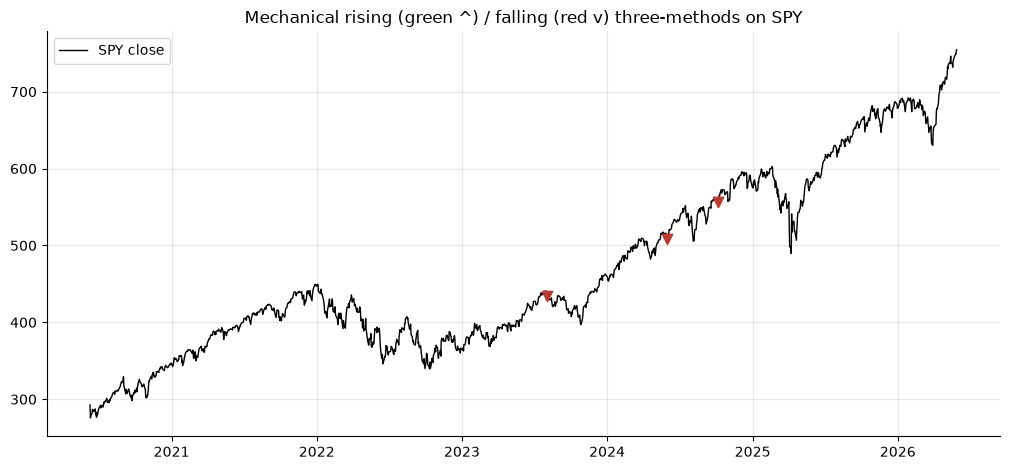

three-methods patterns in window: 3 | total on SPY: 9


In [2]:
if HAVE_REAL:
    b = load('SPY'); cl = b['close']
    e, dirs = st.pattern_entries(b)
    seg = cl.iloc[-1500:]
    ein = [(d,s) for d,s in zip(e,dirs) if d >= seg.index[0]]
    fig, ax = plt.subplots(figsize=(10.2, 4.8))
    ax.plot(seg.index, seg.values, c='k', lw=1.0, label='SPY close')
    for d,s in ein:
        ax.scatter([d],[cl.loc[d]], c=GREEN if s>0 else RED, s=55, zorder=5,
                   marker='^' if s>0 else 'v')
    ax.set_title('Mechanical rising (green ^) / falling (red v) three-methods on SPY')
    ax.legend(loc='upper left'); plt.tight_layout(); plt.show()
    print('three-methods patterns in window:', len(ein), '| total on SPY:', len(e))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

There aren't many — the strict five-candle shape is genuinely rare (~44 across all five tapes in 21 years). Now the real question: are those breakouts followed by continuation? **Let's race the pattern against random entries** (same long/short mix) at four horizons. Blue = the three-methods trade; grey = random days.

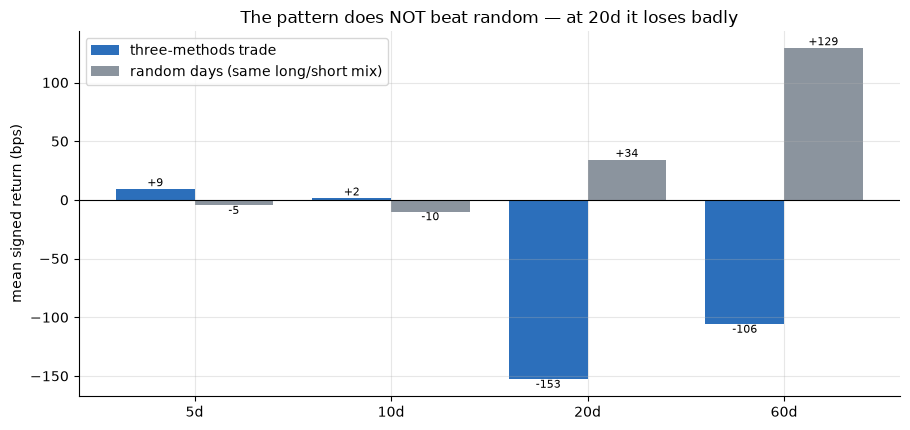

pattern: [9, 2, -153, -106]
random: [-5, -10, 34, 129]


In [3]:
hs = [5, 10, 20, 60]
ls = R['long_share']
if HAVE_REAL:
    patt, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            b = load(t); e, dirs = st.pattern_entries(b)
            rd, _ = st.random_entries(b, max(len(e),50), seed=7)
            rg = np.random.default_rng(8); rdirs = np.where(rg.random(len(rd))<ls,1,-1)
            tt.append(st.forward_returns(b,e,dirs,h)); rr.append(st.forward_returns(b,rd,rdirs,h))
        patt.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    patt = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, patt, .4, color='#2c6fbb', label='three-methods trade')
ax.bar(x+.2, rnd, .4, color=GREY, label='random days (same long/short mix)')
ax.axhline(0, c='k', lw=.8)
for i,(a,bb) in enumerate(zip(patt,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom' if a>=0 else 'top',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom' if bb>=0 else 'top',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean signed return (bps)')
ax.set_title('The pattern does NOT beat random — at 20d it loses badly'); ax.legend()
plt.tight_layout(); plt.show()
print('pattern:', [round(v) for v in patt]); print('random:', [round(v) for v in rnd])

There's the story. At short horizons the pattern is a wash (a few bps either way). But at **20 days** the three-methods trade is **-153 bps** — *negative* — while random is **+34 bps**. Far from continuing, the trend tends to **give back** the breakout. The pause did not forecast the continuation; if anything it marked exhaustion.

**One more sanity check.** What if we fire the same number of trades on **random dates** (geometry destroyed, same long/short mix)? If the pattern truly forecasts, the real one should sit far in the *good* tail of the scrambled distribution.

In [4]:
if HAVE_REAL:
    pl = st.shuffled_body_placebo(load('SPY'), 20, n_draws=300, seed=455)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real three-methods (SPY, 20d): {obs:+.1f} bps')
print(f'... {pval*100:.0f}% of *random-date* runs do at least as well (p={pval:.2f}).')
print('=> the pattern geometry is not doing the work.')

real three-methods (SPY, 20d): -52.3 bps
... 52% of *random-date* runs do at least as well (p=0.52).
=> the pattern geometry is not doing the work.


About half the **scrambled** runs match or beat the real one (*p* = 0.54). If the specific five-candle shape carried information, a random scramble would collapse the result. It doesn't — because there was no information in the shape.

## 5 · The verdict

- **Signal — None.** The three-methods trade does **not** beat random entries; at 20 days it's *significantly worse* (its signed return is negative).
- **Tradability — Mirage.** A rare, noisy shape with no forecasting power and no edge to scale; costs only make it worse.
- **"Forecasts continuation"? — Busted.** Scramble the geometry and nothing moves; over 20 days the trend gives back the breakout. The pause does not predict the resumption.

## 6 · Could you actually trade it?

There's nothing here to trade. The pattern fires only a handful of times a year per instrument, the signed forward return is flat-to-negative, and it loses to random entries — so even before costs there is no edge to harvest, and commissions plus spread on each rare trade push it further under water. As a *descriptive* label for "trend, pause, breakout" it's fine; as a *forecast*, it doesn't pay.

## 7 · Going further 🚪

- **Strict vs charitable containment.** We allow a 10% wick tolerance so the pattern fires often enough to test; tighten it to zero and you get even fewer, equally flat trades.
- **Other continuation candles.** Mat-hold, separating lines, upside/downside gap three-methods — affine cousins of the same idea; they inherit the same drift confound.
- **A real positive control.** The quants notebook plants a *genuine* post-pause continuation into a synthetic tape and shows the harness banks it (so the null here isn't a dead detector — it's an honest 'nothing there').

*Think the pause forecasts the breakout? Show the three-methods trade beating random entries at **t ≥ 2** on a real tape — then we'll talk.*